In [1]:
import pandas as pd

In [2]:
instances = pd.read_json(
    r"D:\FinalYearProject2Own\dataset\dataset\instances.jsonl",
    lines=True)


In [3]:
truth = pd.read_json(
    r"D:\FinalYearProject2Own\dataset\dataset\truth.jsonl",
    lines=True
)

In [4]:
df = pd.merge(
    instances,
    truth,
    on="id"
)

print(df.shape)

(19538, 14)


In [5]:
print(df.columns)

Index(['postMedia', 'postText', 'id', 'targetCaptions', 'targetParagraphs',
       'targetTitle', 'postTimestamp', 'targetKeywords', 'targetDescription',
       'truthJudgments', 'truthMean', 'truthClass', 'truthMedian',
       'truthMode'],
      dtype='object')


In [6]:
df.sample(5)

,postMedia,postText,id,targetCaptions,targetParagraphs,targetTitle,postTimestamp,targetKeywords,targetDescription,truthJudgments,truthMean,truthClass,truthMedian,truthMode
3449,[],[.@JoeBiden tells @realDonaldTrump to 'grow up...,817294979005579264,[The head of US intelligence says Russia's hac...,[United States Vice-President Joe Biden has is...,Trump's America US election hacking claims: Jo...,Fri Jan 06 09:01:22 +0000 2017,"hacking, emails, vladimir putin, donald trump,...",US Vice-President Joe Biden tells Donald Trump...,"[0.33333333330000003, 0.0, 0.0, 0.0, 0.0]",0.066667,no-clickbait,0.000000,0.000000
18162,[],[Lesbian and bisexual women are being incorrec...,841563299892342784,[Gynecologist performing a cervical smear or p...,[Women who have sex with women are often wrong...,Lesbian and bisexual women are being incorrect...,Tue Mar 14 08:15:00 +0000 2017,"Women,LGBTQ,Sexual health,Standard,NHS,UK News...",Women who have sex with women are often wrongl...,"[0.6666666666000001, 0.0, 0.0, 0.0, 0.0]",0.133333,no-clickbait,0.000000,0.000000
7703,[],[Theresa May's new economic adviser supported ...,807731624485986304,[Prime Minister Theresa May with Chancellor Ph...,[Theresa May’s new economics adviser Douglas M...,Theresa May's new economic adviser supported t...,Sat Dec 10 23:40:00 +0000 2016,"Autumn Statement,Theresa May,Standard,Philip H...",Theresa May&rsquo;s new economics adviser Doug...,"[0.6666666666000001, 0.0, 0.0, 0.0, 0.0]",0.133333,no-clickbait,0.000000,0.000000
4390,[],"[""My colleague saw bodies lying on the floor a...",844907591595634688,"[The New York Times, Basic, All Access, Home D...",[Shots were heard near Britain’s Parliament on...,Deadly Attack Near U.K. Parliament; Car Plows ...,Thu Mar 23 13:44:02 +0000 2017,"Westminster Attack (March 2017),London (Engla...","Prime Minister Theresa May, who was hastily ev...","[0.33333333330000003, 1.0, 0.6666666666000001,...",0.533333,clickbait,0.666667,0.666667
9799,[],"[Trump praises Jim DeMint, who soon might be o...",858062580132302848,[President Trump thanked the Heritage Foundati...,[ATLANTA — President Trump on Friday gave a sh...,"Trump praises Jim DeMint, who soon might be ou...",Fri Apr 28 20:57:15 +0000 2017,trump demint,Trump praised the former senator in his speech...,"[0.6666666666000001, 0.0, 0.0, 0.0, 0.0]",0.133333,no-clickbait,0.000000,0.000000


In [7]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt to C:\Users\ANKON
[nltk_data]     BANERJEE\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
df['word_count'] = df['targetParagraphs'].apply(lambda x: len(word_tokenize(str(x))))

In [9]:
print(df['word_count'].describe())

count    19538.000000
mean       750.520831
std        893.243795
min          4.000000
25%        309.000000
50%        542.000000
75%        942.000000
max      40091.000000
Name: word_count, dtype: float64


In [10]:
df.sample(100)

,postMedia,postText,id,targetCaptions,targetParagraphs,targetTitle,postTimestamp,targetKeywords,targetDescription,truthJudgments,truthMean,truthClass,truthMedian,truthMode,word_count
2942,[],[.@cpyne says Government has 'no intention' of...,831803391781122048,[Christopher Pyne],[Senior Coalition Minister Christopher Pyne sa...,NDIS debate: Pyne says Government has 'no inte...,Wed Feb 15 09:52:37 +0000 2017,"ndis, christoper pyne, mathias cormann, tax in...",Senior Coalition Minister Christopher Pyne say...,"[0.0, 0.0, 0.0, 0.0, 0.33333333330000003]",0.066667,no-clickbait,0.000000,0.000000,700
19072,[media/photo_816745974227877888.jpg],"[The 22 best ""Rain Drop, Drop Top” tweets]",816746033208180736,"[The 22 Best &quot;Rain Drop, Drop Top&quot; T...","[“should i buy this guy fieri crop top”, Unles...","The 22 Best ""Rain Drop, Drop Top"" Tweets",Wed Jan 04 20:40:03 +0000 2017,,,"[0.6666666666000001, 1.0, 0.6666666666000001, ...",0.866667,clickbait,1.000000,1.000000,142
10490,[media/photo_838391369047687171.jpg],[Israel is relaxing its laws on marijuana use],838391371375472640,[],"[Reuters, Mar. 5, 2017, 8:18 AM 7, facebook li...",Israel is relaxing its laws on marijuana use,Sun Mar 05 14:10:54 +0000 2017,,The Israeli government has voted in favor of d...,"[0.33333333330000003, 0.6666666666000001, 0.0,...",0.200000,no-clickbait,0.000000,0.000000,526
17390,[media/photo_808933095260954624.jpg],[Here’s how Saudi Arabia is keen to emulate th...,808933097454571520,[Saudi Arabia Said to Pick Firms for 'National...,[Saudi Arabia has hired consultants to advise ...,Saudi Arabia Wants to Take Its Biggest and Bes...,Wed Dec 14 07:14:14 +0000 2016,world,Saudi Arabia has hired consultants to advise o...,"[0.6666666666000001, 0.6666666666000001, 0.333...",0.666667,clickbait,0.666667,0.666667,523
18288,[],[All those signs just ready for pickup 🤔],837829191563358208,"[sessions2, President Trump Demands Investigat...","[Right on cue, the George Soros-financed MoveO...","Right On Cue, Soros-Financed MoveOn.Org Holds ...",Sat Mar 04 00:57:00 +0000 2017,"Congress, Donald Trump, George Soros, Jeff Ses...","Right On Cue, Soros-Financed MoveOn.Org Holds ...","[1.0, 1.0, 0.0, 0.0, 0.33333333330000003]",0.466667,no-clickbait,0.333333,0.000000,1076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12440,[media/photo_839561249579024384.jpg],[Tebow strikes out in first spring training at...,839561274333749248,[],[Tim Tebow made his first start of the spring ...,Tim Tebow Strikes out on 4 Pitches in 1st Spri...,Wed Mar 08 19:39:40 +0000 2017,"MLB, Breaking News",Tim Tebow made his first start of the spring f...,"[0.33333333330000003, 0.0, 0.0, 0.0, 0.0]",0.066667,no-clickbait,0.000000,0.000000,165
9158,[],"[Avalanches are becoming more common, thanks t...",822317397394661376,[A hotel in central Italy was hit by an avalan...,[An avalanche buried an Italian resort on Wedn...,"Avalanches are becoming more common, thanks to...",Fri Jan 20 05:38:40 +0000 2017,Alps,Was the Italian ski resort disaster the result...,"[0.0, 0.0, 0.33333333330000003, 0.0, 0.3333333...",0.133333,no-clickbait,0.000000,0.000000,713
14554,[media/photo_835301811905003520.jpg],"['Doomsday' vault receives 50,000 new deposits]",835301814430019584,[FILE - This is a March 2. 2016 file photo of...,"[More, HELSINKI (AP) — Nearly 10 years after a...","Arctic 'doomsday' seed vault receives 50,000 n...",Sat Feb 25 01:34:06 +0000 2017,,"HELSINKI (AP) — Nearly 10 years after a ""dooms...","[0.33333333330000003, 0.6666666666000001, 0.33...",0.466667,no-clickbait,0.333333,0.333333,991
18929,[],[The New York City venue where a young Bob Dyl...,820718476885114880,[Val Wilmer/Redferns Bob Dylan],[Bob Dylan would surely still recognize the lo...,New York Venue Where a Young Bob Dylan Played ...,Sun Jan 15 19:45:07 +0000 2017,,Bob Dylan would surely still recognize the low...,"[0.0, 0.6666666666000001, 0.33333333330000003,...",0.400000,no-clickbait,0.333333,0.333333,777


In [11]:
new_df= df[
    ["postText","targetParagraphs","targetTitle","targetDescription",
    "truthMean"
    ]
].copy()

In [12]:
new_df["postText"] = new_df["postText"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

new_df["targetParagraphs"] = new_df["targetParagraphs"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

new_df["targetTitle"] = new_df["targetTitle"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

new_df["targetDescription"] = new_df["targetDescription"].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

In [13]:
new_df["inputtext"] = (
    new_df["postText"] + " " +
    new_df["targetTitle"] + " " +
    new_df["targetDescription"] + " " +
    new_df["targetParagraphs"]
)

In [14]:
new_df['word_count'] = new_df['inputtext'].apply(lambda x: len(word_tokenize(str(x))))

In [15]:
print(new_df['word_count'].describe())

count    19538.000000
mean       755.597502
std        849.766832
min         17.000000
25%        339.000000
50%        555.000000
75%        938.000000
max      38719.000000
Name: word_count, dtype: float64


In [16]:
len(new_df)

19538

In [17]:
new_df.drop_duplicates(
    subset=["inputtext"],
    inplace=True
)

print("Remaining Samples:", len(new_df))

Remaining Samples: 19286


In [18]:
def clickbait_level(value):
    if value <= 0.33:
        return "Low Clickbait"
    elif value <= 0.66:
        return "Moderate Clickbait"
    else:
        return "High Clickbait"

new_df["Clickbait Category"] = new_df["truthMean"].apply(clickbait_level)

In [19]:
new_df.drop(
    columns=["truthMean","postText","targetParagraphs","targetTitle","targetDescription"],
    inplace=True)

In [20]:
new_df.sample(5)

,inputtext,word_count,Clickbait Category
2323,Suspect in St. Petersburg blast identified by ...,397,Low Clickbait
15094,"All French banks have refused to meet me, Mari...",231,Low Clickbait
18401,"""Greatest threat to democracy"": Commander of b...",1248,Low Clickbait
13996,#CRPF sniffer dog who was killed in an explosi...,217,Low Clickbait
8312,Trump just signed on to send people to Mars Do...,488,Moderate Clickbait


In [21]:
import re
import string

In [22]:
def preprocess_text(text):
    # Handle missing values
    if not isinstance(text, str):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Keep only words and numbers (removes punctuation)
    tokens = [word for word in tokens if word.isalnum()]

    # Join tokens back into a string
    return " ".join(tokens)

In [23]:
new_df["Clean_inputtext"] = new_df["inputtext"].apply(
    preprocess_text)


In [24]:
label_map = {
    "Low Clickbait": 0,
    "Moderate Clickbait": 1,
    "High Clickbait": 2
}

new_df["Clickbait Category"] = new_df["Clickbait Category"].map(label_map)

In [25]:
new_df.sample(5)

,inputtext,word_count,Clickbait Category,Clean_inputtext
14899,Scientists are planning their own march on Was...,645,1,scientists are planning their own march on was...
11594,Donald Trump will receive a mechanical Swiss-m...,474,0,donald trump will receive a mechanical timepie...
14952,.@chelseahandler nixes two-party politics: 'I'...,606,0,chelseahandler nixes politics i not a democrat...
3732,Russian hackers were free to roam the DNC’s ne...,9194,0,russian hackers were free to roam the dnc s ne...
13603,Lululemon is soaring after beating on earnings...,292,0,lululemon is soaring after beating on earnings...


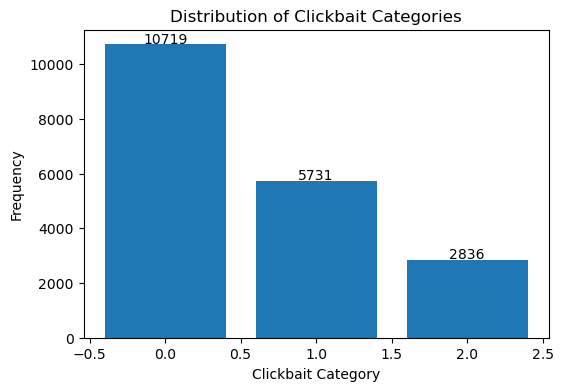

In [26]:
import matplotlib.pyplot as plt

# Count the number of samples in each class
class_counts = new_df["Clickbait Category"].value_counts()

# Create bar plot
plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)

# Labels and title
plt.xlabel("Clickbait Category")
plt.ylabel("Frequency")
plt.title("Distribution of Clickbait Categories")

# Display the count on top of each bar
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 50, str(count), ha='center')

plt.show()

In [27]:
new_df.drop(
    columns=["inputtext"],
    inplace=True
)

In [28]:
from sklearn.model_selection import train_test_split

# Features and target
X = new_df["Clean_inputtext"]
y = new_df["Clickbait Category"]



In [29]:
# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 30% -> 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Print sizes
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

Training: 13500
Validation: 2893
Testing: 2893


In [30]:
# The dataset is first divided into training (70%), validation (15%), and testing (15%) sets before applying TF-IDF to prevent data leakage.
#The TF-IDF vectorizer is fitted only on the training set, where it learns the vocabulary and calculates the Inverse Document Frequency (IDF) values.
#The fitted vectorizer is then used to transform the validation and test sets using the same vocabulary and IDF scores. This ensures that no
#information from the validation or test data influences feature extraction, resulting in an unbiased and reliable evaluation of the model.

from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
     min_df=2,
    max_df=0.95
)  # lowercase=True, removing stopwords  are done automatically by this function

In [31]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfid=tfidf.transform(X_val)
X_test_tfidf=tfidf.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [33]:
lr = LogisticRegression(
    C=0.5,
    random_state=42,
    class_weight="balanced",
    max_iter=1000,)

lr.fit(X_train_tfidf, y_train)



LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [38]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)


MultinomialNB(alpha=0.1)

In [41]:

from sklearn.svm import SVC
svc = SVC(
    C=1.0,
    kernel='linear',   # Linear kernel works best for TF-IDF text data
    random_state=42
)

# Train the model
svc.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [34]:
y_pred=lr.predict(X_test_tfidf)

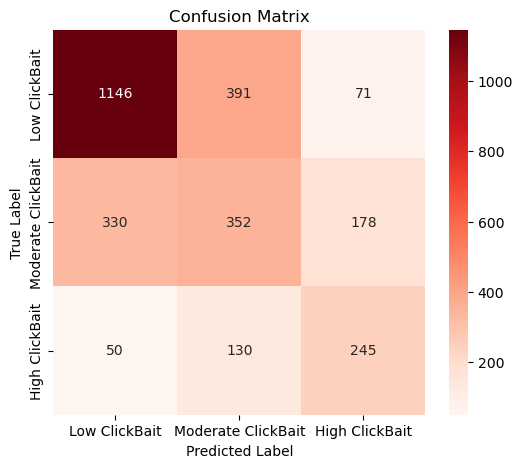

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=["Low ClickBait","Moderate ClickBait","High ClickBait"],
            yticklabels=["Low ClickBait","Moderate ClickBait","High ClickBait"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

#plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

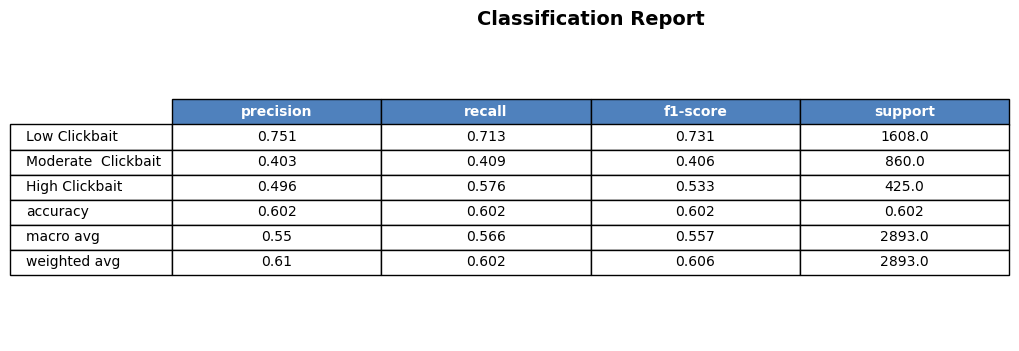

In [36]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Generate classification report
report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose().round(3)
df.rename(index={
    '0': 'Low Clickbait',
    '1': 'Moderate  Clickbait',
    '2': 'High Clickbait'
}, inplace=True)

# Create figure
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

# Create table
table = ax.table(
    cellText=df.values,
    rowLabels=df.index,
    colLabels=df.columns,
    cellLoc='center',
    loc='center'
)

# Font and size
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color only the header row
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#4F81BD")   # Blue header
        cell.set_text_props(color="white", weight="bold")

# Title
plt.title("Classification Report", fontsize=14, fontweight='bold')

# Save image
#plt.savefig("classification_report.png", dpi=300, bbox_inches="tight")

plt.show()

In [44]:
from sklearn.metrics import classification_report
import pandas as pd

f1_results = []

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Support Vector Classifier": svc
}

for name, model in models.items():

    y_pred = model.predict(X_test_tfidf)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    f1_results.append({
        "Model": name,
        "Weighted Precision": report["weighted avg"]["precision"],
        "Weighted Recall": report["weighted avg"]["recall"],
        "Weighted F1-Score": report["weighted avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(f1_results)

# Round all metric columns
metrics_df.iloc[:, 1:] = metrics_df.iloc[:, 1:].round(4)

display(metrics_df)

,Model,Weighted Precision,Weighted Recall,Weighted F1-Score
0,Logistic Regression,0.6101,0.6025,0.6056
1,Naive Bayes,0.6253,0.6315,0.6217
2,Random Forest,0.5835,0.6180,0.5645
3,Support Vector Classifier,0.6066,0.6274,0.6032
